In [2]:
import numpy as np
import os, glob
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

import h5py

from scipy.signal import savgol_filter

from scipy.optimize import curve_fit
from scipy.fft import rfft, irfft, rfftfreq

import sys
sys.path.append('../')
import analysis_utils as utils

utils.load_plotting_setting()

In [3]:
import importlib
importlib.reload(utils)

<module 'analysis_utils' from '/Users/yuhan/work/nanospheres/dm_nanospheres/analysis_notebooks/../analysis_utils.py'>

In [4]:
m = 2000 * (83e-9)**3 * 4 * np.pi / 3
kb = 1.38e-23
hbar = 1.054571817e-34
omega0 = 2 * np.pi * 50292.96875

In [5]:
drive_freq = [143000, 163000]
drive_vpp  = [1, 2, 3, 4]

c_mvs_freqs = [[], []]
for i, freq in enumerate(drive_freq):
    for vpp in drive_vpp:
        data_files = [rf"/Users/yuhan/work/nanospheres/data/pulse_calibration/sphere_20250406/20250412_electric_calibration_2e-8mbar/20250412_d_m8e_{int(freq/1000)}khz_{vpp}vpp_trapping_0.hdf5"]
        c_mvs = utils.get_c_mv(data_files, [vpp], freq*2*np.pi, passband=(freq-1300, freq+1300), charge=8, n_chunk=6, efield=138)

        c_mvs_freqs[i].append(c_mvs)

In [6]:
c_mv = np.mean(np.asarray(c_mvs_freqs))
print(fr'Calibration factor C_mv: {c_mv} \pm {np.std(np.asarray(c_mvs_freqs))}')

Calibration factor C_mv: 6.711030676159362e-08 \pm 2.0316969808876543e-09


## Quick look at the data and decide the analysis window

In [17]:
folder = r'E:\reheating_data\sphere_20250406\1_7e-8mbar'
dataset = r''
combined_path = os.path.join(folder, dataset, '20250412*.hdf5')
data_files = glob.glob(combined_path)

Quick look on the data, and choose an appropriate time window

In [ ]:
fs = 500000

file_name = data_files[5]
f = h5py.File(file_name, 'r')

zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv']/1000
ff = f['data']['channel_f'][:] * f['data']['channel_f'].attrs['adc2mv']/1000

zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)

pulse_idx = drive_indices = utils.get_pulse_idx(ff, 1, True)
f.close()

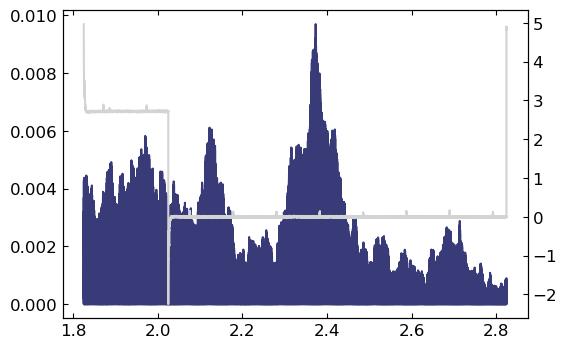

In [11]:
idx = pulse_idx[1]

tt = 2e-6 * np.arange(zz.size)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(tt[idx:idx+500000], zz_bp[idx:idx+500000]**2)
ax.twinx().plot(tt[idx:idx+500000], ff[idx:idx+500000], color='lightgrey')

Calculate ensemble averaged variance

In [ ]:
def get_mean_variance_pressure(pressure):
    # folder = fr'E:\reheating_data\sphere_20250406\{pressure}'
    folder = fr'/Volumes/LaCie/reheating_data/sphere_20250406/{pressure}'
    dataset = r''
    combined_path = os.path.join(folder, dataset, '20250412*.hdf5')
    data_files = glob.glob(combined_path)

    fs = 500000
    window_length = 500000
    var_all = []
    for file in data_files:
        f = h5py.File(file, 'r')
        zz = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv']/1000
        ff = f['data']['channel_f'][:] * f['data']['channel_f'].attrs['adc2mv']/1000
        f.close()

        zz_bp = utils.bandpass_filtered(zz, fs, 30000, 80000)

        pulse_idx = utils.get_pulse_idx(ff, 1, True)
        
        for idx in pulse_idx:
            if idx > zz.size-window_length:
                continue
            var_all.append(zz_bp[idx:idx+window_length]**2)
            
    var_all = np.asarray(var_all)
    return np.mean(var_all, axis=0)

In [13]:
pressure = ['1_7e-8mbar', '4_8e-8mbar', '9_2e-8mbar', '2_2e-7mbar', '1_3e-6mbar']

var_0 = get_mean_variance_pressure(pressure[0])
var_1 = get_mean_variance_pressure(pressure[1])
var_2 = get_mean_variance_pressure(pressure[2])
var_3 = get_mean_variance_pressure(pressure[3])
var_4 = get_mean_variance_pressure(pressure[4])

In [14]:
out_dir = r'/Users/yuhan/work/nanospheres/data/reheating_data/sphere_20250406'
outfile_name = r'reheating_averaged_varaince.h5py'

with h5py.File(os.path.join(out_dir, outfile_name), 'w') as fout:
    print(f'Writing file {os.path.join(out_dir, outfile_name)}')

    g = fout.create_group('averaged_variance')
    g.attrs['c_mv'] = 6.711030676159362e-08

    g.create_dataset('1_7e-8mbar', data=var_0, dtype=np.float64)
    g.create_dataset('4_8e-8mbar', data=var_1, dtype=np.float64)
    g.create_dataset('9_2e-8mbar', data=var_2, dtype=np.float64)
    g.create_dataset('2_2e-7mbar', data=var_3, dtype=np.float64)
    g.create_dataset('1_3e-6mbar', data=var_4, dtype=np.float64)

    fout.close()

Writing file /Users/yuhan/work/nanospheres/data/reheating_data/sphere_20250406/reheating_averaged_varaince.h5py


In [15]:
f = h5py.File(r'/Users/yuhan/work/nanospheres/data/reheating_data/sphere_20250406/reheating_averaged_varaince.h5py')
var_0 = f['averaged_variance']['1_7e-8mbar'][:]
var_1 = f['averaged_variance']['4_8e-8mbar'][:]
var_2 = f['averaged_variance']['9_2e-8mbar'][:]
var_3 = f['averaged_variance']['2_2e-7mbar'][:]
var_4 = f['averaged_variance']['1_3e-6mbar'][:]
f.close()

In [16]:
c_mv = 6.711030676159362e-08

z_var_filtered_0 = savgol_filter(var_0 * c_mv**2, 500, 1)
z_var_filtered_1 = savgol_filter(var_1 * c_mv**2, 500, 1)
z_var_filtered_2 = savgol_filter(var_2 * c_mv**2, 500, 1)
z_var_filtered_3 = savgol_filter(var_3 * c_mv**2, 500, 1)
z_var_filtered_4 = savgol_filter(var_4 * c_mv**2, 500, 1)

#### Perform linear fit to derive heating rate

In [17]:
var_unfiltered = [var_0, var_1, var_2, var_3, var_4]
z_var_filtered = [z_var_filtered_0, z_var_filtered_1, z_var_filtered_2, z_var_filtered_3, z_var_filtered_4]

def func(x, a, b):
    return a*x + b

lb, ub = 30000, 150000

tt = 2e-6 * np.arange(var_0.size)
tt_fit = tt[lb:ub] - tt[lb]

slope_fit = []
for var in var_unfiltered:
    var_mean_fit = var[lb:ub] * c_mv**2
    popt, pcov = curve_fit(func, tt_fit, var_mean_fit)
    slope_fit.append(popt[0])

gamma_heating = 0.5 * m * omega0**2 * np.array(slope_fit) / (hbar * omega0)
gamma_heating_khz = gamma_heating / (2 * np.pi * 1000)

print(gamma_heating_khz)

[ 19.12717739  20.41860165  24.19419219  32.91813421 100.94987011]


In [18]:
pressures = [1.7e-8, 4.8e-8, 9.2e-8, 2.2e-7, 1.3e-6]

popt, pcov = curve_fit(func, pressures, gamma_heating_khz, sigma=gamma_heating_khz*0.15)
gamma_ba, gamma_th = popt[1], popt[0]

print(fr'Measured heating rate @1.7e-8 mbar: {gamma_heating_khz[0]:.3f} \pm {gamma_heating_khz[0]*0.15:.3f} kHz')
print(fr'Fitted photon recoil heating rate: {gamma_ba:.3f} \pm {gamma_ba * 0.15:.3f} kHz')

Measured heating rate @1.7e-8 mbar: 19.127 \pm 2.869 kHz
Fitted photon recoil heating rate: 17.916 \pm 2.687 kHz


#### Perform exponential fit to derive damping rate

In [19]:
def func_expo(x, A, gamma):
    return A * np.exp(-1 * gamma * x)

lb, ub = 300000, 500000

tt_fit = tt[lb:ub] - tt[lb]
gamma_fb_fit = []
for var in var_unfiltered:
    var_mean_fit = var[lb:ub] * c_mv**2
    popt, pcov = curve_fit(func_expo, tt_fit, var_mean_fit)
    gamma_fb_fit.append(popt[1])

gamma_fb_hz = 1 / np.asarray(gamma_fb_fit)
print(fr'Fitted damping rate: {gamma_fb_hz[0]:.2f} \pm {gamma_fb_hz[0]*0.15:.2f} Hz')

Fitted damping rate: 0.34 \pm 0.05 Hz


#### Estimate the predicted thermal decoherence rate

In [20]:
def get_thermal_heating_rate_khz(p_mbar, m_sphere, r_sphere, omega0, gas='hydrogen'):
    kb = 1.38e-23

    p_pascal = p_mbar * 100

    R = 8.3144  # J/(mol K)
    if gas == 'water':
        m_gas = 18.01528e-3
    elif gas == 'hydrogen':
        m_gas = 2.016e-3   # kg / mol
    T = 292     # K
    vbar = np.sqrt(8 * R * T / (np.pi * m_gas))  # m/s

    small_gamma_th = (64/3) * r_sphere**2 * p_pascal / (m_sphere * vbar)
    big_gamma_th = small_gamma_th * kb * T / (hbar * omega0)

    return big_gamma_th / (2 * np.pi * 1000)

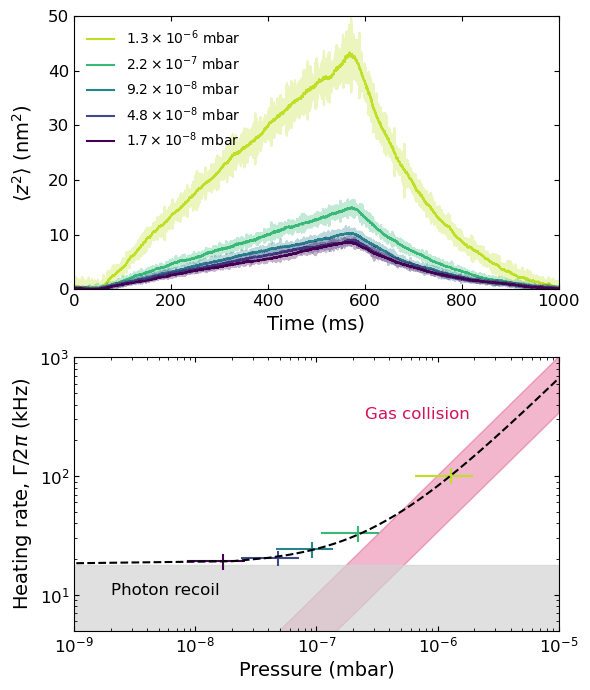

In [23]:
cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.9, 5))

fig, axes = plt.subplots(2, 1, figsize=(6, 7))

labels=[r'$1.7 \times 10^{-8}$ mbar', r'$4.8 \times 10^{-8}$ mbar', r'$9.2 \times 10^{-8}$ mbar', r'$2.2 \times 10^{-7}$ mbar', r'$1.3 \times 10^{-6}$ mbar']

xx = np.linspace(1e-10, 1e-5, 500)
heating_rate_khz_h2 = get_thermal_heating_rate_khz(xx, m, 83e-9, omega0, 'hydrogen')
heating_rate_khz_water = get_thermal_heating_rate_khz(xx, m, 83e-9, omega0, 'water')

# axes[1].plot(xx[heating_rate_khz_h2 > gamma_ba], heating_rate_khz_h2[heating_rate_khz_h2 > gamma_ba], 'k', linewidth=1)
# axes[1].plot(xx[heating_rate_khz_water > gamma_ba], heating_rate_khz_water[heating_rate_khz_water > gamma_ba], 'k', linewidth=1)
axes[1].fill_between(xx, heating_rate_khz_h2, heating_rate_khz_water, color='#D41159', alpha=0.3)

tt = np.arange(500000) * 2e-6
for i, zvar in enumerate(np.flip(np.asarray(z_var_filtered), axis=0)):
    axes[0].plot(tt/1e-3, (var_unfiltered[4-i] * c_mv**2 - np.min(zvar))/1e-18, alpha=0.3, color=colors[4-i])
    axes[0].plot(tt/1e-3, (zvar - np.min(zvar))/1e-18, color=colors[4-i], label=labels[4-i])

    # Assume 15% error on the measured heating rate, dominated by uncertainty in electric field
    # and detection drift
    axes[1].errorbar(pressures[i], gamma_heating_khz[i], xerr=pressures[i]/2, yerr=gamma_heating_khz[i]*0.15, color=colors[i])

axes[1].plot(xx, gamma_ba + gamma_th * xx, 'k--', label='Fit')
axes[1].fill_between(xx, 0, gamma_ba, color='lightgrey', alpha=0.7)

axes[0].set_xlim(0, 1000)
axes[0].set_ylim(0, 50)
axes[0].legend(frameon=False, fontsize=10, loc='upper left')

axes[1].set_xlim(1e-9, 1e-5)
axes[1].set_ylim(5, 1000)
# axes[1].legend(frameon=False, fontsize=12)

axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel(r'$\langle z^2 \rangle$ (nm$^2$)')

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Pressure (mbar)')
axes[1].set_ylabel(r'Heating rate, $\Gamma / 2 \pi$ (kHz)')

axes[1].text(2.5e-7, 300, 'Gas collision', color='#D41159', fontsize=12)
axes[1].text(2e-9, 10, 'Photon recoil', fontsize=12)

fig.align_labels()
fig.tight_layout()

plt.savefig('../paper_plots/reheating_measurement.pdf', dpi=600)

Text(0, 0.5, '$\\gamma_{\\mathrm{FB}} / 2 \\pi$ (Hz)')

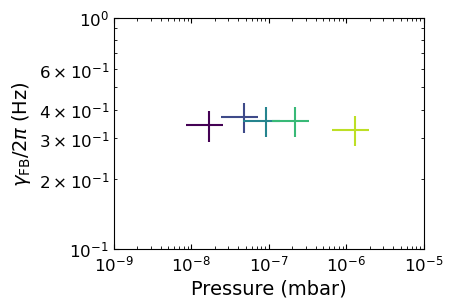

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

for i, gamma_fb in enumerate(gamma_fb_hz):
    ax.errorbar(pressures[i], gamma_fb_hz[i], xerr=pressures[i]/2, yerr=gamma_fb_hz[i]*0.15, color=colors[i])

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e-9, 1e-5)
ax.set_ylim(0.1, 1)

ax.set_xlabel('Pressure (mbar)')
ax.set_ylabel(r'$\gamma_{\mathrm{FB}} / 2 \pi$ (Hz)')